In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import re

In [6]:
#data = pd.read_csv("/Users/mhasan/workingDirectory/moose/results/irrFccSC_out.csv", index_col = None)
#data = pd.read_csv("/Users/mhasan/workingDirectory/moose/result/irrFcc_result_n10/irrFccSC_out.csv", index_col = None)
data = pd.read_csv("/Users/mhasan/projects/irr_crystal_plasticity/irrFCC_single_out.csv", index_col = None)
#data = pd.read_csv("/Users/mhasan/projects/irr_crystal_plasticity/fccSCSlipTwin_out_.csv", index_col = None)
#data = pd.read_csv("/Users/mhasan/projects/irr_crystal_plasticity/fccSCOnlyTwin_out.csv", index_col = None)
#datast = pd.read_csv("/Users/mhasan/projects/irr_crystal_plasticity/fccSCSlipTwin_out.csv", index_col = None)
#datak = pd.read_csv("/Users/mhasan/projects/irr_crystal_plasticity/fccSCOnlyTwinK_out.csv", index_col = None)
#data = pd.read_csv("/Users/mhasan/workingDirectory/moose/result/parallel/refine_40/irrTest_out.csv", index_col = None)
slip_systems = np.loadtxt("/Users/mhasan/projects/irr_crystal_plasticity/input_slip_sys_fcc12.txt")

In [143]:
files = glob.glob("/Users/mlhasan/projects/irr_crystal_plasticity/irr_test/*.csv")

In [144]:
files

['/Users/mhasan/projects/irr_crystal_plasticity/irr_test/irrTest.1e-08_450_out.csv',
 '/Users/mhasan/projects/irr_crystal_plasticity/irr_test/irrTest.10000000000.0_450_out.csv',
 '/Users/mhasan/projects/irr_crystal_plasticity/irr_test/irrTest.0.0001_4500000000.0_out.csv',
 '/Users/mhasan/projects/irr_crystal_plasticity/irr_test/irrTest.10_45000000.0_out.csv',
 '/Users/mhasan/projects/irr_crystal_plasticity/irr_test/irrTest.10000.0_450_out.csv',
 '/Users/mhasan/projects/irr_crystal_plasticity/irr_test/irrTest.100000000.0_450_out.csv',
 '/Users/mhasan/projects/irr_crystal_plasticity/irr_test/irrTest.0.0001_4500000.0_out.csv',
 '/Users/mhasan/projects/irr_crystal_plasticity/irr_test/irrTest.10_4500.0_out.csv',
 '/Users/mhasan/projects/irr_crystal_plasticity/irr_test/irrTest.0.0001_45000000.0_out.csv',
 '/Users/mhasan/projects/irr_crystal_plasticity/irr_test/irrTest.0.0001_450000.0_out.csv',
 '/Users/mhasan/projects/irr_crystal_plasticity/irr_test/irrTest.0.0001_450_out.csv',
 '/Users/mhas

In [131]:
pattern = re.compile(r'.+Test\.(.+)_(.+)_.+')

In [152]:
m = pattern.match(files[14])
m[1]

'0.0001'

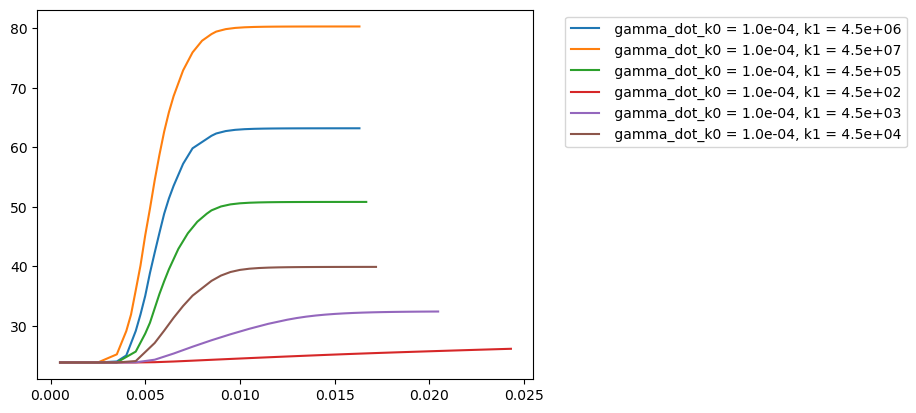

In [141]:
for file in files:
    m = pattern.match(file)
    if m[1] == '0.0001':
        label = f' gamma_dot_k0 = {np.float64(m[1]):.1e}, k1 = {np.float64(m[2]):.1e}'
        data = pd.read_csv(file, index_col = None)
        plt.plot(100*data["time"][1:], data["avg_slip_resistance_dislocation_comp"][1:], label = label)
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left') 

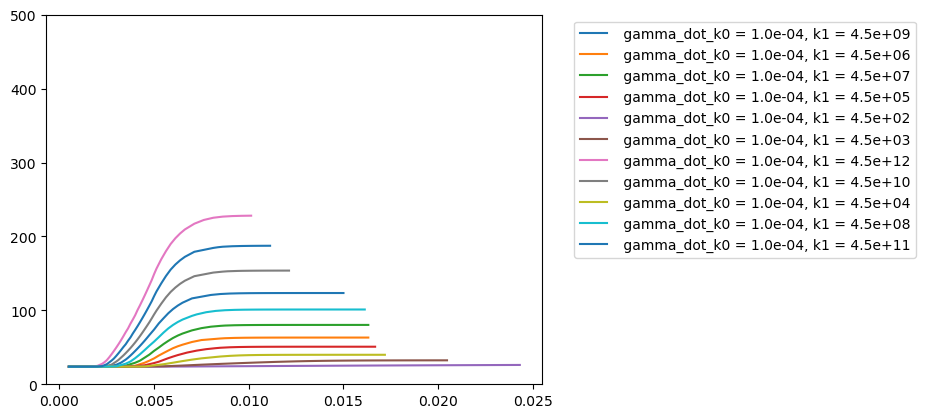

In [153]:
for file in files:
    m = pattern.match(file)
    if m[1] == '0.0001':
        label = f' gamma_dot_k0 = {np.float64(m[1]):.1e}, k1 = {np.float64(m[2]):.1e}'
        data = pd.read_csv(file, index_col = None)
        plt.plot(100*data["time"][1:], data["avg_slip_resistance_dislocation_comp"][1:], label = label)
        plt.ylim([0,500])
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left') 

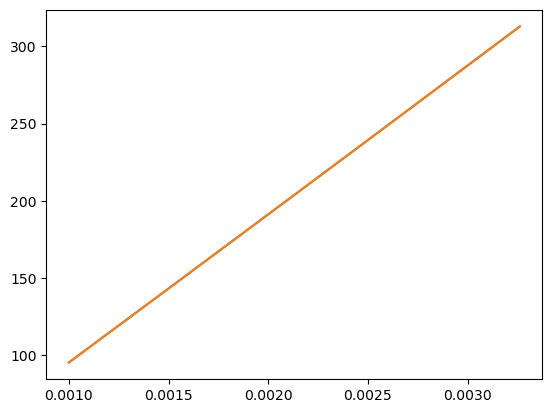

In [7]:
#plt.plot(100*data["time"][1:], data["avg_slip_resistance_dislocation_comp"][1:])
plt.plot(100*data["time"][1:], data["stress_vm"][1:])
plt.plot(100*data["time"][1:], data["stress_zz"][1:])
#plt.ylim([0, 500])
#plt.xlim([0, 0.2])

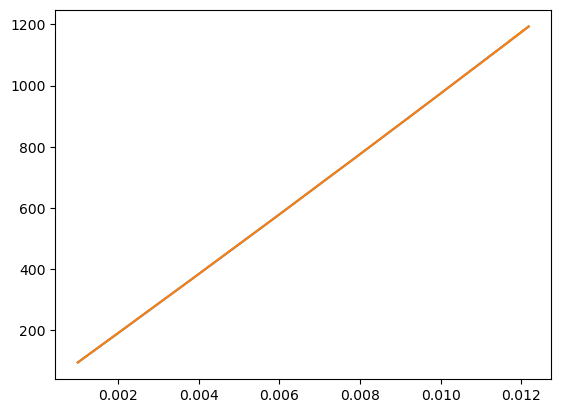

In [25]:
plt.plot(100*data["time"][1:], data["stress_vm"][1:])
plt.plot(100*data["time"][1:], data["stress_zz"][1:])
#plt.ylim([0, 500])

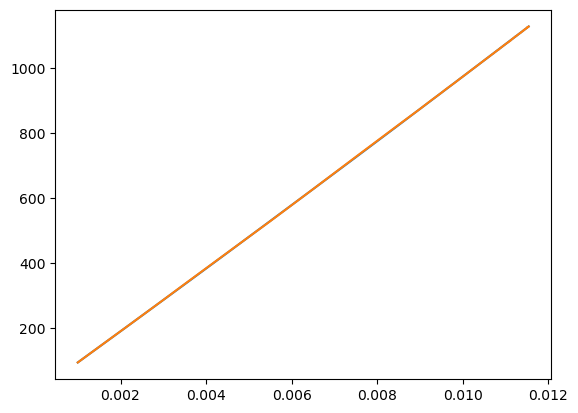

In [7]:
plt.plot(100*data["time"][1:], data["stress_vm"][1:])
plt.plot(100*data["time"][1:], data["stress_zz"][1:])
#plt.ylim([0, 500])

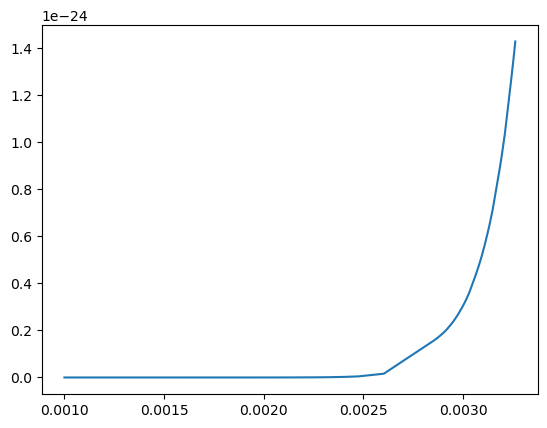

In [8]:
plt.plot(100*data["time"][1:], data["total_twin_volume_fraction"][1:])
#plt.plot(100*datast["time"][1:], datast["total_twin_volume_fraction"][1:])
#plt.plot(100*datak["time"][1:], datak["total_twin_volume_fraction"][1:])
#plt.ylim([0, 500])

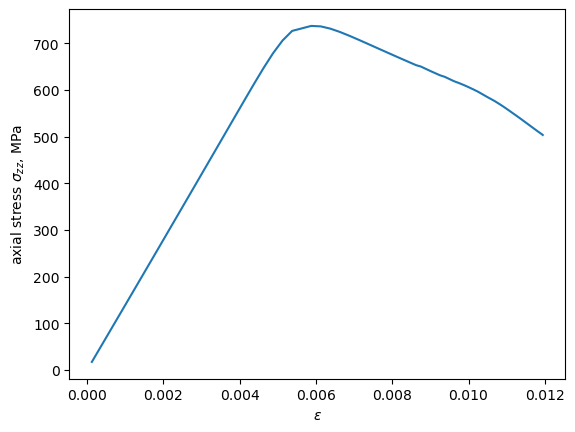

In [16]:
#plt.plot(100*data["time"][1:], data["stress_vm"][1:])
plt.plot(100*data["time"][1:], data["stress_zz"][1:])
plt.xlabel(r'$\epsilon$')
plt.ylabel(r'axial stress $\sigma_{zz}$, MPa')
plt.savefig('/Users/mhasan/Documents/PostDoc/notes/presentation/axial_stress.png', dpi=300)
#plt.ylim([0, 500])

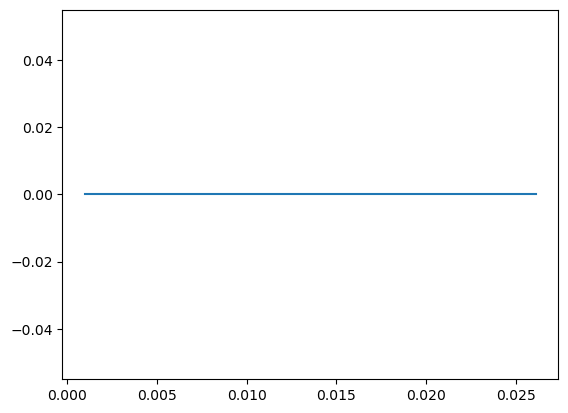

In [8]:
plt.plot(100*data["time"][1:], data["total_twin_volume_fraction"][1:])

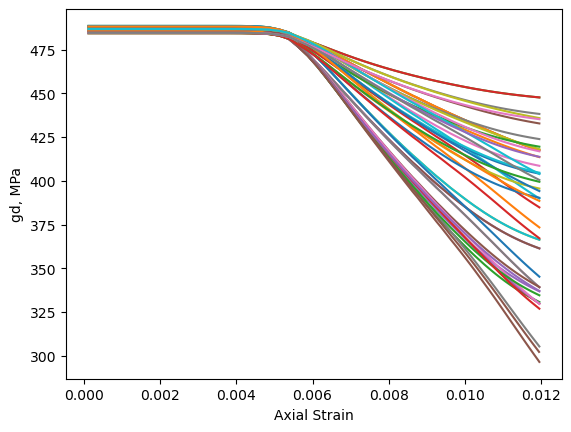

In [23]:
#data = pd.read_csv(files[2], index_col = None)
for i in range(48):
    plt.plot(100*data['time'][1:], data[f'slip_resistance_damage_{i}'][1:], label = f'slip_system{i}')
plt.xlabel("Axial Strain");
plt.ylabel("gd, MPa");
#plt.legend()
plt.savefig("gd_slip_systems.png")

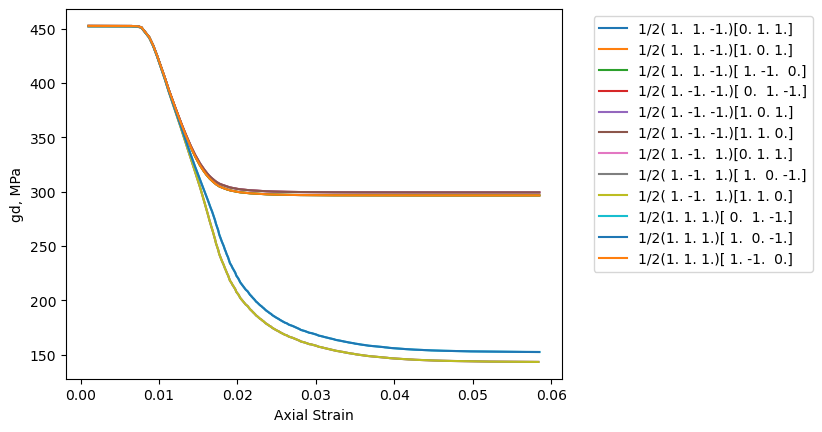

In [138]:
#data = pd.read_csv(files[2], index_col = None)
for i in range(12):
    plt.plot(100*data['time'][1:], data[f'slip_resistance_damage_{i}'][1:], label = f'1/2{str(slip_systems[i][:3]).replace('[', '(').replace(']', ')')}{slip_systems[i][3:6]}')
plt.xlabel("Axial Strain");
plt.ylabel("gd, MPa");
#plt.xlim([0.0, 0.013])
#plt.ylim([350, 460])
plt.legend(bbox_to_anchor=[1.05,1], loc = 'upper left')
#plt.savefig("gd_slip_systems.png")

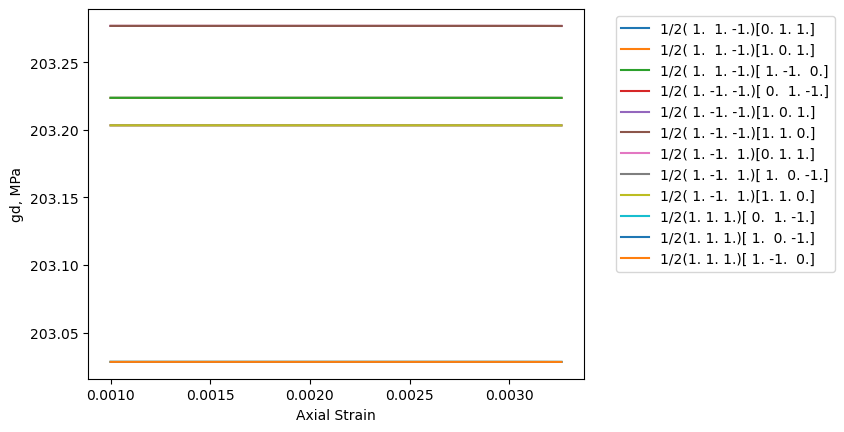

In [9]:
#data = pd.read_csv(files[2], index_col = None)
for i in range(12):
    plt.plot(100*data['time'][1:], data[f'slip_resistance_damage_{i}'][1:], label = f'1/2{str(slip_systems[i][:3]).replace('[', '(').replace(']', ')')}{slip_systems[i][3:6]}')
plt.xlabel("Axial Strain");
plt.ylabel("gd, MPa");
plt.legend(bbox_to_anchor=[1.05,1], loc = 'upper left')
#plt.savefig("gd_slip_systems.png")

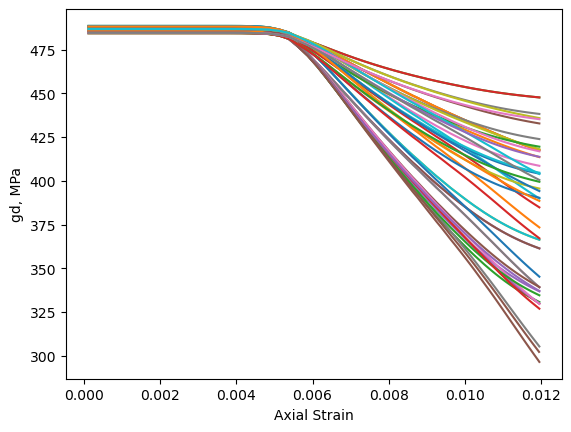

In [23]:
#data = pd.read_csv(files[2], index_col = None)
for i in range(48):
    plt.plot(100*data['time'][1:], data[f'slip_resistance_damage_{i}'][1:], label = f'<{slip_system{i}>')
plt.xlabel("Axial Strain");
plt.ylabel("gd, MPa");
#plt.legend()
plt.savefig("gd_slip_systems.png")

In [47]:
data["time"]

0     0.000000
1     0.000005
2     0.000011
3     0.000017
4     0.000023
        ...   
57    0.000104
58    0.000104
59    0.000104
60    0.000104
61    0.000104
Name: time, Length: 62, dtype: float64

In [22]:
3*10**4 == 3*10E4

False

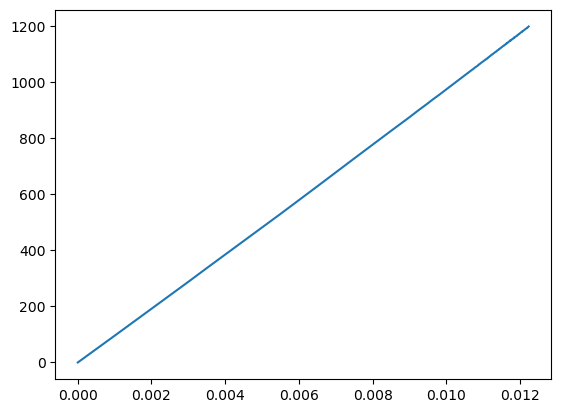

In [9]:
plt.plot(100*data["time"], data["stress_zz"])

In [17]:
data1 = pd.read_csv('/Users/mhasan/projects/Experimental/irr_crystal_plasticity__/irr_test/irrTest.0.0001_4500.0_out.csv')

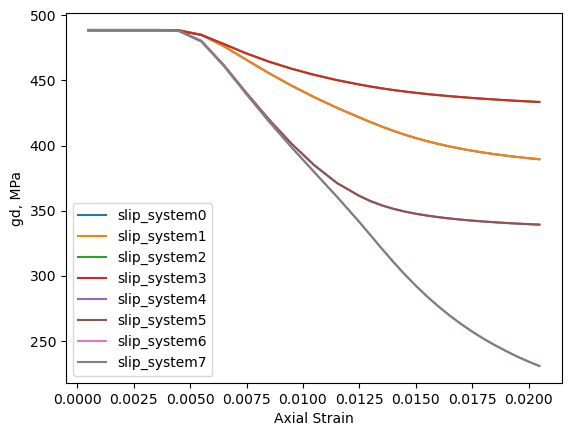

In [43]:
#data = pd.read_csv(files[2], index_col = None)
for i in range(0, 8):
    plt.plot(100*data1['time'][1:], data1[f'slip_resistance_damage_{i}'][1:], label = f'slip_system{i}')
plt.xlabel("Axial Strain");
plt.ylabel("gd, MPa");
plt.legend()
#plt.savefig("/Users/mhasan/Documents/PostDoc/notes/presentation/gd_slip_systems.png")

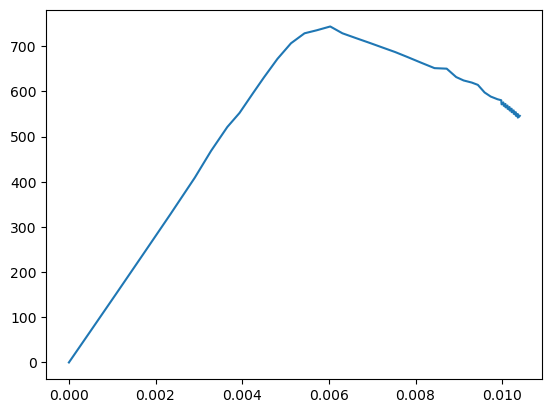

In [27]:
plt.plot(100*data["time"], data["stress_zz"])

In [90]:
(0.3*0.00397)/(3e-3)

0.3969999999999999

In [26]:
(0.3*0.0001218)/(3e-3)

0.01218

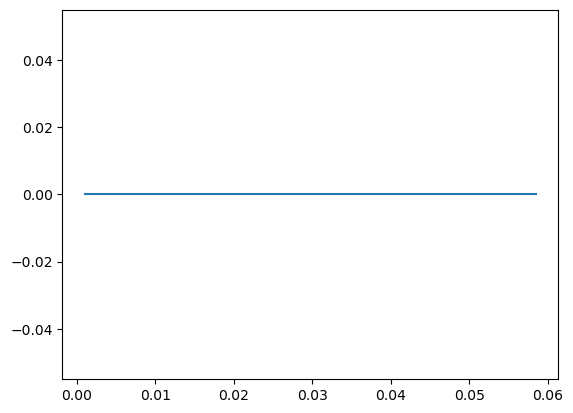

In [100]:
plt.plot(100*data["time"][1:], data["total_twin_volume_fraction"][1:])

In [116]:
slip_systems

array([[ 1.,  1., -1.,  0.,  1.,  1.],
       [ 1.,  1., -1.,  1.,  0.,  1.],
       [ 1.,  1., -1.,  1., -1.,  0.],
       [ 1., -1., -1.,  0.,  1., -1.],
       [ 1., -1., -1.,  1.,  0.,  1.],
       [ 1., -1., -1.,  1.,  1.,  0.],
       [ 1., -1.,  1.,  0.,  1.,  1.],
       [ 1., -1.,  1.,  1.,  0., -1.],
       [ 1., -1.,  1.,  1.,  1.,  0.],
       [ 1.,  1.,  1.,  0.,  1., -1.],
       [ 1.,  1.,  1.,  1.,  0., -1.],
       [ 1.,  1.,  1.,  1., -1.,  0.]])

In [10]:
0**0.5

0.0

In [ ]:
import random
